# Chapter 02-07 · Showing what you found, without saying more than you found

**Label:** Core  |  **Time:** ~50 minutes  |  **Difficulty:** moderate - no new mathematics, but the
habits here are the ones that keep you honest

**Prerequisites:** 02-06. You should be able to explain Simpson's paradox and say why a correlation
of 0.82 does not mean a relationship is close to a straight line.

**Position in the learning path:** module 02, chapter 7 of 8. Before: **02-06**. After: **02-08**,
which puts all seven chapters to work on one real dataset.

---

## Why this matters

Exploration ends with a sentence. Someone asks what you found, and you tell them - in a chart, in a
slide, in a message. That sentence is where analysis turns into a decision, and it is where most of
the damage in this field is actually done.

Not by lying. Almost nobody in this line of work invents numbers. The damage comes from sentences
that are *true* and that carry a stronger claim than the data support - because a chart implied it,
or because a correlation was described with a verb like "drives", or because forty things were
examined and only the interesting one was mentioned.

This chapter is about the gap between what you found and what your audience will hear, and about the
two things exploratory analysis is structurally unable to settle no matter how carefully you do it.

## What you will be able to do

- Spot the two chart patterns that mislead without containing a single false number
- Explain why a scatter plot cannot tell you which way a causal arrow points, and demonstrate it
- Quantify how large a "finding" pure noise produces when you look at many columns at once
- State a finding in a form that survives being challenged
- Say, for a given question, whether exploratory analysis can settle it or only raise it

## Warm-up: retrieve, do not reread

From memory, before scrolling:

1. In the bike trial, electric bikes won at both stations and lost overall. What single fact about
   the data caused that?
2. What did the four Anscombe datasets share, and what did they not share?
3. Why is it a mistake to feed `staff_on_duty` into a model that predicts rentals?
4. When a subgroup answer and a pooled answer disagree, what kind of question decides which to use?

<br>

*Answers: (1) the two bike types were not allocated evenly across stations - three quarters of the
electric bikes sat at the station where everything rents less. (2) they shared mean, variance,
correlation and fitted line to two decimals; they did not share their shape. (3) staff are rostered
in response to expected demand, so it is not available before the thing you are predicting, and it
carries the answer. (4) a causal question - whether the grouping variable is a confounder (use the
subgroups) or a mediator on the path you care about (use the total).*

## The situation

Maria presents to the city transport committee on Tuesday. Fifteen minutes, five slides, and a
committee that will fund a second depot or not fund it.

She has a month of exploration behind her - the docking-rack trial, the rental history, a table of
city statistics somebody sent her. Everything she is about to say is true.

**The question this chapter answers:** what is the difference between a slide that is true and a
slide that is honest?

## Slide one: the new docking racks

Maria trialled a redesigned rack. Two hundred dockings on the old design, two hundred on the new
one, timed from arrival to lock engaged. Lower is better.

Her slide is a bar chart of the two averages.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rng = np.random.default_rng(7)
n = 200

# SYNTHETIC. Docking times in seconds for two rack designs, 200 dockings each.
old = rng.normal(47.0, 11.0, n).round(1)
new = rng.normal(41.0, 11.0, n).round(1)

docking = pd.DataFrame({
    "rack": ["old"] * n + ["new"] * n,
    "seconds": np.concatenate([old, new]),
})

summary = docking.groupby("rack")["seconds"].agg(["mean", "std", "min", "max"]).round(2)
print(summary.to_string())
print("\ndifference of means: %.2f seconds" % (old.mean() - new.mean()))

       mean    std   min   max
rack                          
new   40.13  10.70   5.2  65.8
old   45.54   9.62  19.3  71.7

difference of means: 5.42 seconds


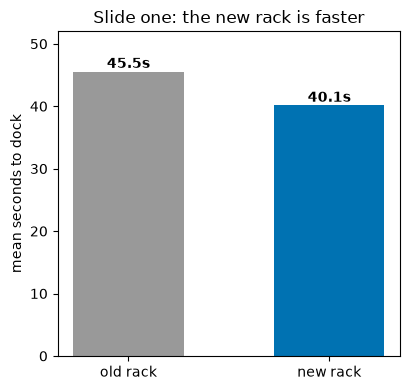

In [2]:
fig, ax = plt.subplots(figsize=(4.2, 4))
means = [old.mean(), new.mean()]
ax.bar(["old rack", "new rack"], means, color=["#999999", "#0072B2"], width=0.55)
for i, m in enumerate(means):
    ax.text(i, m + 0.6, f"{m:.1f}s", ha="center", fontweight="bold")
ax.set_ylabel("mean seconds to dock")
ax.set_title("Slide one: the new rack is faster")
ax.set_ylim(0, 52)
plt.tight_layout()
plt.show()

### Predict before running

The chart is accurate. The mean really did fall by about five and a half seconds, and nothing on
that slide is false.

Before running the next cell, commit to a number for each:

1. Out of 200 dockings on the **new** rack, how many took *longer* than the average docking on the
   old rack?
2. If you picked one docking at random from each design, how often would the new one be faster?
   (50% would mean the redesign does nothing.)

Write both down. The chart above gives you no way to answer them, which is the point.

In [3]:
old_mean, new_mean = old.mean(), new.mean()

print("share of NEW dockings slower than the OLD average : %.3f" % (new > old_mean).mean())
print("share of OLD dockings faster than the NEW average : %.3f" % (old < new_mean).mean())
print("P(a random new docking beats a random old one)    : %.3f"
      % float((new[:, None] < old[None, :]).mean()))
print("\nmedians:  old %.1f s   new %.1f s" % (np.median(old), np.median(new)))

share of NEW dockings slower than the OLD average : 0.285
share of OLD dockings faster than the NEW average : 0.270
P(a random new docking beats a random old one)    : 0.646

medians:  old 45.6 s   new 40.4 s


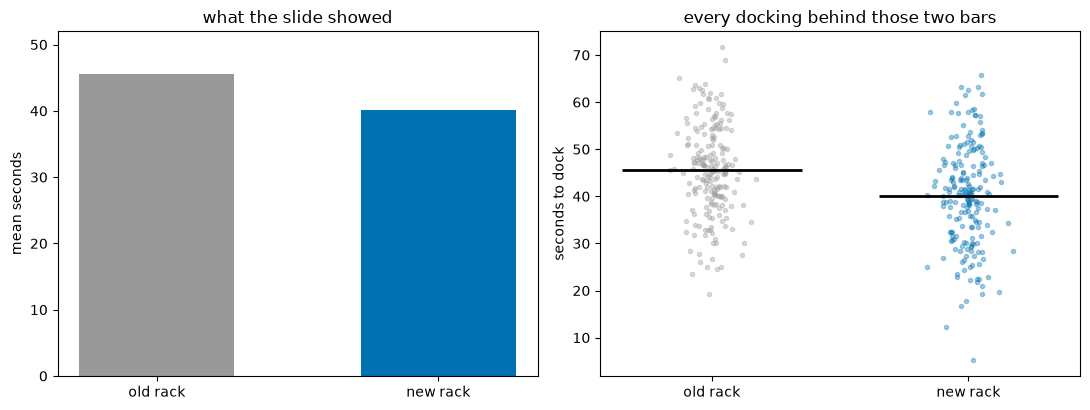

In [4]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.2))

left.bar(["old rack", "new rack"], means, color=["#999999", "#0072B2"], width=0.55)
left.set_ylabel("mean seconds")
left.set_title("what the slide showed")
left.set_ylim(0, 52)

jitter = np.random.default_rng(1).normal(0, 0.06, n)
right.scatter(np.zeros(n) + jitter, old, s=9, alpha=0.35, color="#999999")
right.scatter(np.ones(n) + jitter, new, s=9, alpha=0.35, color="#0072B2")
right.hlines([old_mean, new_mean], [-0.35, 0.65], [0.35, 1.35],
             color="black", linewidth=2)
right.set_xticks([0, 1])
right.set_xticklabels(["old rack", "new rack"])
right.set_ylabel("seconds to dock")
right.set_title("every docking behind those two bars")

plt.tight_layout()
plt.show()

### Diagnosis: the bar was true, the impression was not

Both numbers on the slide are correct. What the slide cannot show is that **the two designs overlap
almost completely**. Around 28% of dockings on the new rack were slower than the *average* docking
on the old one, and a randomly chosen new docking beats a randomly chosen old one only about 65% of
the time - not the near-certainty two clean bars suggest.

Two different claims live in this data, and only one of them is supported:

| Claim | Supported? |
|---|---|
| "The new rack is faster **on average**, by about 5 seconds" | Yes |
| "Riders will find the new rack faster" | No - more than a quarter of the time they will not |

A bar chart of means answers *"which group is higher on average"* and nothing else. If your audience
will act on individual cases - one rider, one patient, one customer - the average is the wrong
summary and the bar chart is the wrong chart.

**When two bars are fine:** when the decision really is about the total. Maria is buying racks for
the whole city and cares about total rider-seconds across a million dockings; there the mean is
exactly the right summary. The chart is only dishonest if she says "riders will notice".

**The habit:** before drawing a summary, ask *what varies underneath it, and does my audience need
to see that variation?* Show the spread whenever the answer is yes - a strip plot, a box plot, or
simply the sentence "the ranges overlap heavily".

## Slide two: rentals and parking permits

Somebody on the committee sent Maria a table of city statistics and suggested a story: parking
permits have been rising for three years, and so have bike rentals. Squeezing drivers pushes people
onto bikes.

Two series, three years, monthly. She puts them on one chart with two vertical axes.

In [5]:
gen = np.random.default_rng(53)
months = 36

# SYNTHETIC, and generated INDEPENDENTLY - by construction neither series
# influences the other. Each is a random walk with an upward drift.
rentals = 100 + np.cumsum(gen.normal(2.0, 6.0, months))
permits = 20 + np.cumsum(gen.normal(0.6, 2.5, months))

period = pd.period_range("2023-01", periods=months, freq="M")
city = pd.DataFrame({"month": period.astype(str), "rentals": rentals.round(1),
                     "permits": permits.round(1)})
print(city.head(4).to_string(index=False))
print("...")
print(city.tail(3).to_string(index=False))

  month  rentals  permits
2023-01    102.6     17.3
2023-02     99.8     17.9
2023-03    107.1     15.4
2023-04    103.6     17.8
...
  month  rentals  permits
2025-10    175.5     39.5
2025-11    185.7     42.8
2025-12    182.3     42.4


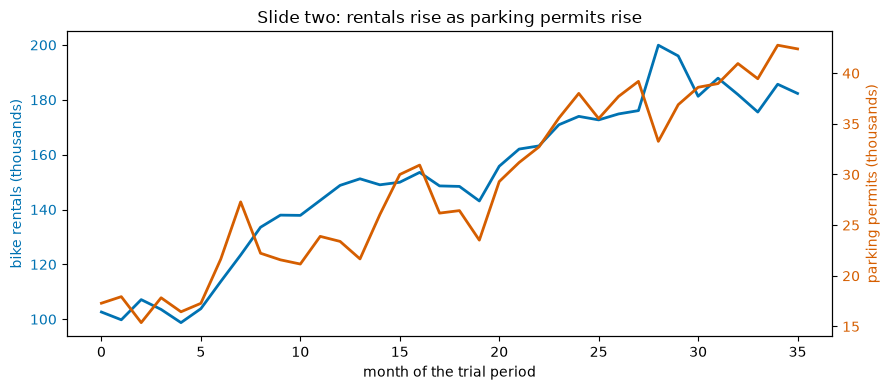

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(months), rentals, color="#0072B2", linewidth=2, label="bike rentals (thousands)")
ax.set_ylabel("bike rentals (thousands)", color="#0072B2")
ax.tick_params(axis="y", labelcolor="#0072B2")

twin = ax.twinx()
twin.plot(range(months), permits, color="#D55E00", linewidth=2, label="parking permits (thousands)")
twin.set_ylabel("parking permits (thousands)", color="#D55E00")
twin.tick_params(axis="y", labelcolor="#D55E00")

ax.set_xlabel("month of the trial period")
ax.set_title("Slide two: rentals rise as parking permits rise")
plt.tight_layout()
plt.show()

### Predict before running

The two lines track each other closely. Before running the next cell:

1. What do you expect the correlation between the two **levels** to be?
2. Now consider the **month-to-month changes** - not "how high is each series" but "did each go up
   or down this month". What do you expect the correlation of the changes to be?

The gap between your two answers is the whole lesson.

correlation of the levels           : 0.914
correlation of the monthly changes  : -0.011


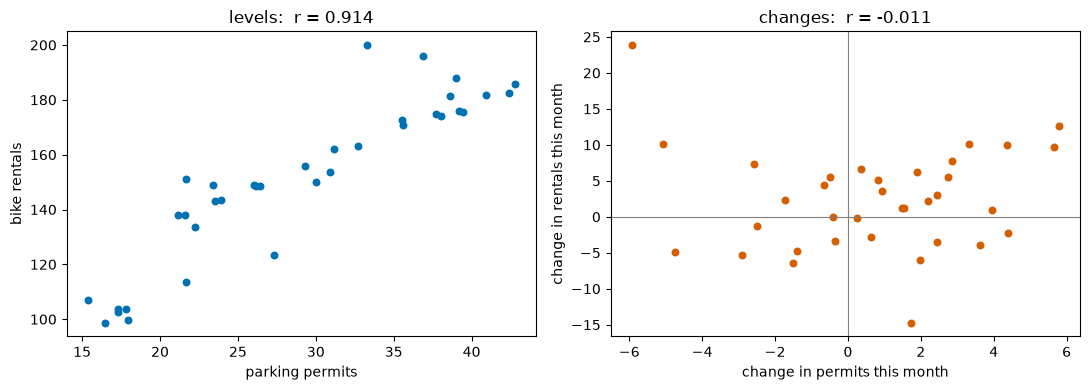

In [7]:
r_levels = np.corrcoef(rentals, permits)[0, 1]
r_changes = np.corrcoef(np.diff(rentals), np.diff(permits))[0, 1]

print("correlation of the levels           : %.3f" % r_levels)
print("correlation of the monthly changes  : %.3f" % r_changes)

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
left.scatter(permits, rentals, s=22, color="#0072B2")
left.set_xlabel("parking permits")
left.set_ylabel("bike rentals")
left.set_title(f"levels:  r = {r_levels:.3f}")

right.scatter(np.diff(permits), np.diff(rentals), s=22, color="#D55E00")
right.axhline(0, color="grey", linewidth=0.8)
right.axvline(0, color="grey", linewidth=0.8)
right.set_xlabel("change in permits this month")
right.set_ylabel("change in rentals this month")
right.set_title(f"changes:  r = {r_changes:.3f}")
plt.tight_layout()
plt.show()

### Diagnosis: they share a direction, not a relationship

Look at how the two series were built. Each one is `previous value + a random step, with a small
upward drift`. Nothing in that code lets either series see the other. They are, by construction,
unrelated - and they correlate at **0.914**.

Any two series that drift upward will correlate strongly, because correlation on levels is mostly
asking *"are both of these high at the same times?"* and for trending series the answer is
automatically yes: both are low at the start and high at the end. The correlation is measuring the
calendar, not the mechanism.

The month-to-month changes are the honest question - *when permits move more than usual, do rentals
move more than usual?* - and the answer here is **-0.011**, which is nothing.

**The habits:**

- Two vertical axes let you slide two series onto each other until they appear to touch. The choice
  of scales is yours, and it determines the visual story. Be suspicious of every twin-axis chart,
  including your own.
- Before correlating two series over time, **difference them** - correlate the changes, not the
  levels. Module 09 makes this precise; for now the rule is enough.
- If two things both grow, "they are related" is not a finding. Nearly everything in a growing city
  correlates with nearly everything else.

## Failure lab: three worlds that look identical

Slide three is Maria's best finding. Riders who open more of her loyalty emails take more rides -
a clear, strong relationship, correlation 0.754. The recommendation writes itself: send more emails.

Below are three worlds. In each one, 300 riders have an email-opens number and a rides number. The
three worlds have **completely different mechanisms**:

- in one, **opening emails causes riding** - the email reminds you the bike is there;
- in one, **riding causes opening** - people who ride a lot pay attention to bike emails;
- in one, **neither causes the other** - keen cyclists both ride more and open more, and the emails
  themselves do nothing at all.

The three panels are shuffled. Look at them and decide which is which.

In [8]:
N = 300

def standardise(v):
    return (v - v.mean()) / v.std()

# World "x causes y": opens are drawn first, rides follow from opens.
g1 = np.random.default_rng(3)
opens_1 = g1.normal(0, 1, N)
rides_1 = 0.80 * opens_1 + g1.normal(0, 0.78, N)

# World "y causes x": rides are drawn first, opens follow from rides.
g2 = np.random.default_rng(3)
rides_2 = g2.normal(0, 1, N)
opens_2 = 0.80 * rides_2 + g2.normal(0, 0.78, N)

# World "a third thing causes both": enthusiasm is drawn first and drives each
# of them separately. Nothing passes between opens and rides.
g3 = np.random.default_rng(17)
enthusiasm = g3.normal(0, 1, N)
opens_3 = 0.90 * enthusiasm + g3.normal(0, 0.514, N)
rides_3 = 0.90 * enthusiasm + g3.normal(0, 0.514, N)

worlds = {
    "A": (opens_3, rides_3),
    "B": (opens_1, rides_1),
    "C": (opens_2, rides_2),
}

for name, (x, y) in worlds.items():
    print("world %s :  r = %.3f" % (name, np.corrcoef(x, y)[0, 1]))

world A :  r = 0.754
world B :  r = 0.754
world C :  r = 0.754


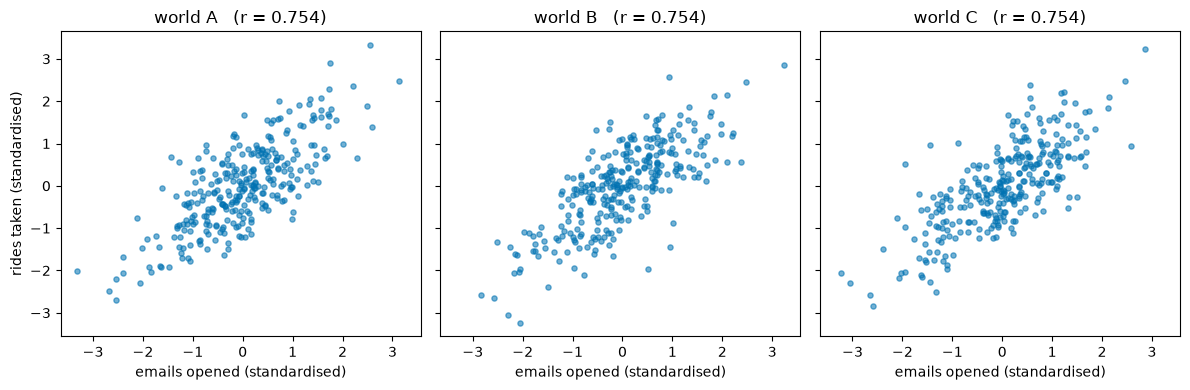

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
for ax, (name, (x, y)) in zip(axes, worlds.items()):
    ax.scatter(standardise(x), standardise(y), s=14, alpha=0.55, color="#0072B2")
    ax.set_title(f"world {name}   (r = {np.corrcoef(x, y)[0, 1]:.3f})")
    ax.set_xlabel("emails opened (standardised)")
axes[0].set_ylabel("rides taken (standardised)")
plt.tight_layout()
plt.show()

### Which is which?

Write down your three guesses before running the reveal.

The correlations are **0.754, 0.754 and 0.754**. The clouds are standardised, so the spreads match
too. There is no tell. Any guess you made was a coin toss between three options, and the next cell
will tell you which mechanism produced which panel - a fact that is in the code that generated the
data and **nowhere in the data itself**.

In [10]:
reveal = pd.DataFrame({
    "panel": ["A", "B", "C"],
    "mechanism": ["enthusiasm causes both", "opens cause rides", "rides cause opens"],
    "arrow": ["opens <- enthusiasm -> rides", "opens -> rides", "rides -> opens"],
})
print(reveal.to_string(index=False))

panel              mechanism                        arrow
    A enthusiasm causes both opens <- enthusiasm -> rides
    B      opens cause rides               opens -> rides
    C      rides cause opens               rides -> opens


### The part that matters: the decision differs, the data do not

Maria's recommendation is to send more emails. That is not a claim about correlation - it is a claim
about what happens **if she intervenes**. Because these worlds are synthetic, the generating rule is
available and the intervention can simply be run: set everyone's email opens one standard deviation
higher and recompute rides *under each mechanism*.

In [11]:
# World B (opens -> rides): rides are computed FROM opens, so forcing opens up
# changes rides. The individual noise term is held fixed - only opens are moved.
g = np.random.default_rng(3)
opens_b = g.normal(0, 1, N)
noise_b = g.normal(0, 0.78, N)
rides_before = 0.80 * opens_b + noise_b
rides_after = 0.80 * (opens_b + 1.0) + noise_b

# Worlds A and C: nothing downstream of opens. Rides are produced by enthusiasm
# (A) or drawn first (C), so moving opens leaves every rides value untouched.
effect = pd.DataFrame({
    "panel": ["A", "B", "C"],
    "mechanism": ["enthusiasm causes both", "opens cause rides", "rides cause opens"],
    "observed r": [0.754, 0.754, 0.754],
    "change in mean rides if she sends more emails": [
        0.000,
        round(float(rides_after.mean() - rides_before.mean()), 3),
        0.000,
    ],
})
print(effect.to_string(index=False))

panel              mechanism  observed r  change in mean rides if she sends more emails
    A enthusiasm causes both       0.754                                            0.0
    B      opens cause rides       0.754                                            0.8
    C      rides cause opens       0.754                                            0.0


### Diagnosis: a scatter plot has no arrow in it

Same correlation, same cloud, same slide - and a one-standard-deviation push on email opens is
worth **0.800 extra rides in one world and exactly zero in the other two**. If Maria's real world is A or C, the
email budget buys nothing, and the relationship on her slide will still be there afterwards to
reassure her.

This is not a limitation of correlation as a statistic. Fitting a line, a tree, or a neural network
to these three datasets gives the same answer in all three cases, because the datasets are the same.
**No method applied to observational data can recover the direction of an arrow that the data do not
contain.**

What *can* distinguish the worlds, none of which is a technique:

| Evidence | What it settles |
|---|---|
| **An experiment** - randomise who gets emails | Everything. Randomisation cuts every arrow into "opens" and leaves only the one out of it. This is why 00-04's randomised campaign recovered the true effect with no adjustment |
| **Timing** - opens recorded strictly before rides, at the individual level | Rules out "rides cause opens". Does not rule out a common cause |
| **Mechanism** - a plausible, checkable story for how the effect would work | Weak on its own; a story exists for every direction |
| **A natural experiment** - an outage, a policy change, a staggered rollout | Sometimes as good as an experiment; the subject of module 12 |

**The three questions to ask of any correlation, in order:**

1. Could it run the other way?
2. What could cause both?
3. What would I expect to see if there were no effect at all - and do I see something different?

**And a vocabulary rule you can enforce on yourself.** Observational findings get verbs like
*is associated with*, *tends to accompany*, *predicts*. Verbs like *drives*, *causes*, *leads to*,
*boosts* and *reduces* are reserved for evidence that can carry them. This sounds pedantic until
you notice that the causal verb is what makes the budget move.

## Failure lab 2: the more places you look, the more you find

Slide four is Maria's list of "signals worth investigating". Over the month she pulled in whatever
the city and her own system could give her - weather variables, event counts, road works, holiday
flags, social media mentions, forty columns in the end - and checked each against a rider-satisfaction
score for 80 survey days.

One column stood out. Below is the same procedure run on data where **every column is pure noise and
so is the target**. Nothing is related to anything.

In [12]:
noise_rng = np.random.default_rng(42)
n_days, n_candidates = 80, 40

# SYNTHETIC and deliberately meaningless: 40 candidate columns and one target,
# all independent standard normal draws. There is no relationship to find.
candidates = noise_rng.normal(0, 1, (n_days, n_candidates))
satisfaction = noise_rng.normal(0, 1, n_days)

r_each = np.array([np.corrcoef(candidates[:, j], satisfaction)[0, 1]
                   for j in range(n_candidates)])

order = np.argsort(-np.abs(r_each))[:5]
top5 = pd.DataFrame({
    "column": [f"q{j:02d}" for j in order],
    "r": r_each[order].round(3),
})
print(top5.to_string(index=False))
print("\ncolumns with |r| above 0.20: %d out of %d" % ((np.abs(r_each) > 0.20).sum(), n_candidates))

winner = int(order[0])
print("\nHeadline: 'q%02d correlates with satisfaction at r = %.3f'" % (winner, r_each[winner]))

column      r
   q11  0.254
   q09 -0.221
   q23 -0.202
   q29  0.202
   q04  0.194

columns with |r| above 0.20: 4 out of 40

Headline: 'q11 correlates with satisfaction at r = 0.254'


### Predict before running

`q11` correlates with satisfaction at 0.254. Presented alone, on a slide, with a scatter plot and a
fitted line, that is a perfectly respectable-looking finding.

Before running the next cell:

1. What do you expect `q11`'s correlation to be on a **fresh** 80 days from the same generator?
2. When you look at 40 unrelated columns, how large do you expect the *best* of them to be? Guess a
   number for the typical case.

In [13]:
fresh = noise_rng.normal(0, 1, (n_days, n_candidates))
fresh_target = noise_rng.normal(0, 1, n_days)
print("q%02d on the original 80 days : r = %+.3f" % (winner, r_each[winner]))
print("q%02d on a fresh 80 days      : r = %+.3f"
      % (winner, np.corrcoef(fresh[:, winner], fresh_target)[0, 1]))

q11 on the original 80 days : r = +0.254
q11 on a fresh 80 days      : r = -0.045


In [14]:
def best_abs_r(matrix, target):
    # |correlation| between every column of `matrix` and `target`.
    ms = (matrix - matrix.mean(0)) / matrix.std(0)
    ts = (target - target.mean()) / target.std()
    return np.abs(ms.T @ ts / len(target))


sim = np.random.default_rng(0)
runs = 2000
best_of_40 = np.array([best_abs_r(sim.normal(0, 1, (n_days, n_candidates)),
                                 sim.normal(0, 1, n_days)).max() for _ in range(runs)])

sim_one = np.random.default_rng(1)
just_one = np.array([best_abs_r(sim_one.normal(0, 1, (n_days, 1)),
                                sim_one.normal(0, 1, n_days))[0] for _ in range(runs)])

print("Pure noise, 80 rows, %d runs each." % runs)
print()
print("looking at ONE pre-chosen column   : median |r| %.3f   90th pct %.3f"
      % (np.median(just_one), np.quantile(just_one, 0.9)))
print("keeping the BEST of 40 columns     : median |r| %.3f   90th pct %.3f   largest seen %.3f"
      % (np.median(best_of_40), np.quantile(best_of_40, 0.9), best_of_40.max()))
print()
print("share of noise runs that beat Maria's 0.254 finding:")
print("   one pre-chosen column : %.3f" % (just_one > 0.254).mean())
print("   best of 40 columns    : %.3f" % (best_of_40 > 0.254).mean())

Pure noise, 80 rows, 2000 runs each.

looking at ONE pre-chosen column   : median |r| 0.074   90th pct 0.181
keeping the BEST of 40 columns     : median |r| 0.264   90th pct 0.332   largest seen 0.443

share of noise runs that beat Maria's 0.254 finding:
   one pre-chosen column : 0.021
   best of 40 columns    : 0.601


### Diagnosis: the finding is below average for noise

Maria's headline, `r = 0.254`, is *smaller than the median result of doing the same search on data
with nothing in it*. Sixty percent of pure-noise runs produce a better-looking best column than her
best column. It did not survive a fresh 80 days, where it came back at **-0.045**.

The mechanism is arithmetic, not bad luck. Any single correlation on 80 rows wanders around zero;
half the time it lands beyond 0.074, and one time in ten beyond 0.181. Take the largest of forty
such wanderings and you have selected for the extreme by construction. **The search itself
manufactures the finding.** The winner is reported and the thirty-nine losers are never mentioned,
so nobody - including you - can see how many chances the number had.

This is the same shape as the memoriser in 00-01 and it is the shape of most of module 07. Anything
chosen by looking at the data will look better on that data than it is.

**Three fixes, in increasing order of strength:**

1. **Say how many you looked at.** "The best of forty candidates correlated at 0.25" is a completely
   different sentence from "q11 correlates at 0.25", and it costs one clause.
2. **Hold data back.** Decide the shortlist on part of the data, then check the survivors on a part
   you have not touched. The check has to be run once - checking repeatedly on the held-out data
   turns it into training data. This is the whole subject of 04-03.
3. **Decide the question before looking.** A relationship you predicted in advance and then found is
   evidence. The same relationship noticed after the fact is a hypothesis. Both are useful; only one
   of them is a result.

**And the reporting habit:** an exploratory finding is written as *"worth testing"*, never as
*"we found"*. Maria's slide four should say: "Forty candidate variables were screened; the strongest
was q11 at 0.25, which is within the range this screening produces on unrelated data. Recommend
collecting a further month before pursuing it." That sentence is less exciting and it will not have
to be retracted.

## What exploratory analysis can and cannot settle

Module 02 has been one long argument that looking at data carefully is difficult and worth doing.
This is the other half of that argument: there are questions no amount of careful looking will
answer, and knowing which is which is what separates an analyst from a person with a chart.

| Question | Can EDA settle it? |
|---|---|
| What is in this dataset, and what does one row mean? | **Yes** - that is exactly what it is for |
| Is this column recorded consistently over time? | **Yes** - 02-02's changepoint scan |
| Who is missing from this sample? | **Partly** - you can find the gap you thought to check; 02-03's censoring stayed invisible until asked about |
| Is this value an error, or real and rare? | **No, not from the data alone** - 02-05 needed the festival calendar |
| Is this relationship real, or the best of forty looks? | **Only with a plan** - held-out data, or a question fixed in advance |
| Which way does the arrow point? | **No** - the three worlds above |
| What happens if we change something? | **No** - that needs an experiment or a causal argument |
| Is a model going to work here? | **No** - EDA raises the hypothesis; module 04 onwards tests it |

The pattern: exploration is excellent at **description** and at **generating** questions. It cannot
**confirm** anything, because the same data that suggested a finding cannot also be the test of it.
Everything in the "no" column needs either new data or knowledge from outside the dataset.

### A finding, written honestly

Four lines. If you cannot fill all four in, you have a question rather than a finding.

1. **The claim**, in the weakest verb that is still true: "electric bikes are associated with a
   higher rental rate at both stations".
2. **The evidence**, with its size and its sample: "0.93 versus 0.87 at north (357 bikes) and 0.73
   versus 0.69 at south (343 bikes)".
3. **What else could produce this**, named rather than implied: "electric bikes were placed
   unevenly; the pooled figure reverses. Riders may also self-select".
4. **What would change my mind**, stated in advance: "an even allocation next month should keep the
   per-station gap; if it disappears, placement was the whole story".

Line 4 is the one people skip and the one that makes the rest credible.

## Common misconceptions

**"A chart is honest as long as every number on it is correct."**
Every number on both of Maria's slides was correct. Honesty is a property of the *impression*, which
you control through what you choose to show, aggregate, and leave out.

**"Correlation does not imply causation, but strong correlation does."**
The three worlds had identical correlations of 0.754. Strength tells you how tight the cloud is;
nothing about strength contains a direction. A correlation of 0.99 between two trending series is
still a correlation between two trends.

**"Correlation does not imply causation, so correlation is useless."**
The opposite error, and more expensive. Correlations are exactly what prediction runs on - if
umbrella sales predict rain, use them, and do not sell umbrellas expecting a drought. The
distinction from 00-04 is about which *question* the correlation is allowed to answer.

**"I looked at forty columns but I only believed the one that was interesting, so I was careful."**
Believing selectively *is* the search. The number of comparisons you made is set by how many you
looked at, not by how many you reported.

**"Exploration found it, so it is in the data."**
It is in *this* sample of the data. Whether it is in the next sample is a separate question that
exploration cannot ask, because it has already used the data up.

**"If I show the uncertainty, nobody will act on my finding."**
Sometimes true, and usually the correct outcome. A finding that only survives while the uncertainty
is hidden is a finding that was going to fail after the money was spent, with your name on it.

## Exercises

Work in the empty cell below. Solutions are in
`solutions/02_data_literacy/02-07_honest_visuals_solutions.ipynb` - attempt each one first; reading
a solution you have not attempted feels like learning and is not.

### Quick understanding

**E1.** In one sentence, why can no algorithm applied to the three worlds tell them apart?

**E2.** Rentals and parking permits correlated at 0.914 on levels and -0.011 on changes. Which
number answers "do these two things move together", and why is the other one not wrong, merely
answering something else?

**E3.** Maria says "the new rack is faster, riders will feel the difference". Which half of that
sentence does the data support, and what number would you quote to correct the other half?

### Hand calculation

**E4.** A single correlation on 80 rows exceeds 0.181 about one time in ten. If you check 10
independent columns against a target and nothing is related, what is the chance that *at least one*
comes back above 0.181? Compute it, then say what that implies for a dashboard with 10 charts on it.

**E5.** Two bar charts show mean delivery times of 30 and 34 minutes. In dataset P both groups have
a standard deviation of 2 minutes; in dataset Q both have 15. The bars are identical. Sketch what
the strip plot looks like in each, and say which of the two supports the sentence "customers will
notice".

### Coding

**E6.** Write `overlap_report(a, b)` that takes two arrays and prints the difference of means, the
share of `b` beyond `a`'s mean, and the probability that a random draw from `b` beats a random draw
from `a`. Run it on the docking data and on a pair where the same mean difference is unmissable.

**E7.** Repeat the multiple-looks experiment with 5, 20, 40 and 100 candidate columns, holding the
row count at 80. Report the median best `|r|` for each. Plot the four points. What is the shape?

**E8.** Take the `rentals` and `permits` series and write a function that reports the correlation of
the levels and of the changes side by side, with a printed warning when the two disagree by more
than 0.5. Test it on both this pair and a pair you construct that *is* genuinely related.

### Interpretation

**E9.** A colleague's chart shows website conversions and support tickets on twin axes over two
years, both rising, captioned "support load tracks conversion - we need to hire". Name three things
you would check before agreeing, in the order you would check them.

**E10.** A health study reports that people who take vitamin D supplements have fewer respiratory
infections, based on survey data. Give one plausible story for each of the three worlds - supplements
help, being healthy causes supplementing, and a common cause - and say which single study design
would separate them.

### Debugging

**E11.** An analyst writes: *"We tested 200 feature-target correlations and found 11 significant at
the 5% level, so at least some of these are real."* There are two separate errors in that reasoning.
Name both. Approximately how many would you expect if nothing at all were related?

### Exam and interview reasoning

**E12.** "Give an example of a time your analysis found something that turned out not to be real,
and what you changed." Write a five-sentence answer using the multiple-looks experiment as the
example. Interviewers ask this to find out whether you have a process, not whether you have been
wrong.

### Transfer to a different situation

**E13.** A hospital finds that patients treated in the new wing have a lower death rate than those
in the old wing. Write the four-line honest finding for this claim. Then name the single piece of
information you would most want before the hospital acts on it.

### Explain it to someone non-technical

**E14.** Maria's committee chair says: "You told us emails and riding go together. Why won't you
tell us to send more emails?" Answer in under 100 words, without using the words correlation,
causation, confounder or variable.

### Optional challenge

**E15.** Build the three-worlds demonstration yourself from scratch with a different correlation
target - say 0.60 - and confirm the three panels are indistinguishable. Then add a **fourth** world
in which opens cause rides *and* rides cause opens, tuned to the same correlation. Can you tell it
apart from the other three? What would it take to?

In [15]:
# Your workspace. Still in memory: docking, old, new, rentals, permits, city,
# worlds, r_each, candidates, satisfaction, best_of_40, just_one, best_abs_r.

## Mastery check

You have this chapter when you can, without looking back:

- [ ] Name two ways a chart can mislead while every number on it is correct, and give the fix for each
- [ ] Explain why the three worlds cannot be told apart, and name what evidence would tell them apart
- [ ] State roughly how large the best of forty correlations gets on 80 rows of pure noise
- [ ] Write a finding in the four-line form, including line 4
- [ ] Decide, for a new question, whether exploration can settle it or only raise it

## What should now feel instinctive

- Seeing a bar chart of averages and immediately wondering what the spread underneath looks like
- Seeing two rising lines and asking about the changes rather than the levels
- Hearing "drives" or "boosts" applied to observational data and mentally downgrading it to
  "goes with"
- Asking "how many things did you check?" before asking "how strong is it?"
- Writing "worth testing" instead of "we found", and not feeling that this weakens you

## Flashcards

| Front | Back |
|---|---|
| Bar chart of two means | Answers "which group is higher on average" - nothing about individuals |
| Two rising series correlate at 0.9 | Says almost nothing; correlate the changes instead |
| Twin axes | The scales are a choice, and the choice makes the story |
| Three worlds, one correlation | Direction is not in the data; it comes from experiment, timing or mechanism |
| Best of 40 columns, 80 rows, pure noise | Typically about 0.26 - bigger than most "findings" |
| The single-look benchmark on 80 rows | Median 0.07, one in ten beyond 0.18 |
| Honest finding | Claim, evidence, alternatives, what would change my mind |
| Observational verb list | "is associated with", "tends to", "predicts" - not "drives" |

## Next

**02-08 · A full exploratory analysis and a written data dictionary.** Seven chapters of separate
skills - rows, provenance, sampling, quality, distributions, pairs, and honest reporting - applied
end to end to one real dataset, finishing with the document you hand to the next person. It is the
longest chapter in the module and the first one that produces a deliverable rather than an insight.